# 1: IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import warnings
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import folium
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")


warnings.filterwarnings("ignore")

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Environment ready.")

Pandas version: 2.2.3
NumPy version: 2.1.3
Environment ready.


# 2: CONNECT GOOGLE DRIVE

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


# 3: PROJECT PATHS

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/Telangana_PDS_Project")

RAW_DIR = PROJECT_DIR / "raw"

LOCATION_DIR = PROJECT_DIR / "table1_locations"
CARD_DIR = PROJECT_DIR / "table2_card_status"
TRANSACTION_DIR = PROJECT_DIR / "table3_transactions"

MASTER_DIR = PROJECT_DIR / "master"
PROCESSED_DIR = PROJECT_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "figures"
REPORT_DIR = PROJECT_DIR / "reports"

# Create folders if they don't exist
for folder in [MASTER_DIR, PROCESSED_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR]:folder.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Master:", MASTER_DIR)
print("Raw:", RAW_DIR)

Project: /content/drive/MyDrive/Telangana_PDS_Project
Master: /content/drive/MyDrive/Telangana_PDS_Project/master
Raw: /content/drive/MyDrive/Telangana_PDS_Project/raw


# 4: CHECK RAW FILES

In [ ]:
location_files = sorted(LOCATION_DIR.glob("*.csv"))
card_files = sorted(CARD_DIR.glob("*.csv"))
transaction_files = sorted(TRANSACTION_DIR.glob("*.csv"))

print("Location files     :", len(location_files))
print("Card Status files  :", len(card_files))
print("Transaction files  :", len(transaction_files))

Location files     : 1
Card Status files  : 30
Transaction files  : 29


In [ ]:
print("\nLocation files:")
for file in location_files:
    print(" -", file.name)

print("\nFirst 5 Card Status files:")
for file in card_files[:5]:
    print(" -", file.name)

print("\nFirst 5 Transaction files:")
for file in transaction_files[:5]:
    print(" -", file.name)


Location files:
 - shop-status-details_6_2025.csv

First 5 Card Status files:
 - 2023_10_Shop Card Status Data.csv
 - 2023_11_Shop Card Status Data.csv
 - 2023_12_Shop Card Status Data.csv
 - 2023_1_Shop Card Status Data.csv
 - 2023_2_Shop Card Status Data.csv

First 5 Transaction files:
 - 2023_10_Shop Wise Transactions Data.csv
 - 2023_11_Shop Wise Transactions Data.csv
 - 2023_12_Shop Wise Transactions Data.csv
 - 2023_1_Shop Wise Transactions Data.csv
 - 2023_2_Shop Wise Transactions Data.csv


# 5: CHECK FILE SIZES

In [ ]:
def get_size_mb(file):
    return file.stat().st_size / (1024 ** 2)

print("Location file size:")
for file in location_files:
    print(f"{file.name}: {get_size_mb(file):.2f} MB")

print("\nCard Status total size:")
print(f"{sum(get_size_mb(f) for f in card_files):.2f} MB")

print("\nTransaction total size:")
print(f"{sum(get_size_mb(f) for f in transaction_files):.2f} MB")

Location file size:
shop-status-details_6_2025.csv: 2.48 MB

Card Status total size:
57.45 MB

Transaction total size:
48.47 MB


# 6: SAFE CSV READER

In [ ]:
def read_csv_safe(file_path):
    """Safely read a CSV file.
    Tries UTF-8 first and falls back to
    Windows encoding if necessary."""

    try:
        df = pd.read_csv(file_path, low_memory=False)

    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding="latin1", low_memory=False)

    return df

# 7: TEST ONE TRANSACTION FILE

In [ ]:
test_file = transaction_files[0]

test_df = read_csv_safe(test_file)

print("File:", test_file.name)
print("Rows:", test_df.shape[0])
print("Columns:", test_df.shape[1])

display(test_df.head())

File: 2023_10_Shop Wise Transactions Data.csv
Rows: 17221
Columns: 19


,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt
0,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,17427.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35
1,532,Adilabad,532001,Talamadugu,1901002,10,2023,520,522,700.0,9798.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24
2,532,Adilabad,532001,Talamadugu,1901003,10,2023,266,266,595.0,4872.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18
3,532,Adilabad,532001,Talamadugu,1901004,10,2023,368,369,490.0,7239.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,19
4,532,Adilabad,532001,Talamadugu,1901005,10,2023,914,914,5355.0,16098.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17221 entries, 0 to 17220
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distCode           17221 non-null  int64  
 1   distName           17221 non-null  object 
 2   officeCode         17221 non-null  int64  
 3   officeName         17221 non-null  object 
 4   shopNo             17221 non-null  int64  
 5   month              17221 non-null  int64  
 6   year               17221 non-null  int64  
 7   noOfRcs            17221 non-null  int64  
 8   noOfTrans          17221 non-null  int64  
 9   riceAfsc           17221 non-null  float64
 10  riceFsc            17221 non-null  float64
 11  riceAap            17221 non-null  float64
 12  wheat              17221 non-null  float64
 13  sugar              17221 non-null  float64
 14  rgdal              17221 non-null  float64
 15  kerosene           17221 non-null  float64
 16  totalAmount        172

In [ ]:
test_df.columns.tolist()

['distCode',
 'distName',
 'officeCode',
 'officeName',
 'shopNo',
 'month',
 'year',
 'noOfRcs',
 'noOfTrans',
 'riceAfsc',
 'riceFsc',
 'riceAap',
 'wheat',
 'sugar',
 'rgdal',
 'kerosene',
 'totalAmount',
 'salt',
 'otherShopTransCnt']

# 8: CHECK TRANSACTION COLUMN CONSISTENCY

In [ ]:
transaction_columns = {}

for file in transaction_files:
    df_temp = read_csv_safe(file)
    transaction_columns[file.name] = list(df_temp.columns)
    del df_temp

unique_column_sets = {
    tuple(columns)
    for columns in transaction_columns.values()}

print("Different transaction column structures:", len(unique_column_sets))

Different transaction column structures: 1


# 9.a. CARD STATUS COLUMN CHECK

In [ ]:
card_columns = {}

for file in card_files:
    df_temp = read_csv_safe(file)
    card_columns[file.name] = list(df_temp.columns)
    del df_temp


unique_card_column_sets = {tuple(columns)
    for columns in card_columns.values()}

print("Different card-status column structures:",
    len(unique_card_column_sets))

Different card-status column structures: 1


# 9.a. LOCATION COLUMN CHECK

In [ ]:
location_df = read_csv_safe(location_files[0])

print("Location rows:",len(location_df))
print("Location columns:",len(location_df.columns))

display(location_df.head())

Location rows: 17434
Location columns: 11


,distCode,distName,officeCode,officeName,shopNo,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901002,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901003,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901004,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901005,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30


In [ ]:
display(location_df.fillna(0))

,distCode,distName,officeCode,officeName,shopNo,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901002,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901003,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901004,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901005,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
...,...,...,...,...,...,...,...,...,...,...,...
17429,982,Narayanpet,982012,Krishna,4612008,SHIVARAJ ALAMPALLY,77.362910,16.475223,Active,Normal Shop,2025-07-03 14:44:03.763814+05:30
17430,982,Narayanpet,982012,Krishna,4612009,SRINU HINDPOOR,77.346762,16.413360,Active,Normal Shop,2025-07-03 14:44:03.763814+05:30
17431,982,Narayanpet,982012,Krishna,4612010,GOURAMMA CHEGUNTA,77.312684,16.477318,Active,Normal Shop,2025-07-03 14:44:03.763814+05:30
17432,982,Narayanpet,982012,Krishna,4612011,CHANDPASHA THANGIDIGI,77.317855,16.409945,Active,Normal Shop,2025-07-03 14:44:03.763814+05:30


# 10: STANDARDIZE COLUMN NAMES

In [ ]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_"))
    return df

In [ ]:
test_df = clean_column_names(test_df)

print(test_df.columns.tolist())

['distCode', 'distName', 'officeCode', 'officeName', 'shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap', 'wheat', 'sugar', 'rgdal', 'kerosene', 'totalAmount', 'salt', 'otherShopTransCnt']


# 11: CLEAN TEXT COLUMNS

In [ ]:
def clean_text_columns(df):
    df = df.copy()
    text_columns = df.select_dtypes(include=["object"]).columns

    for col in text_columns:
        df[col] = (df[col].astype("string").str.strip())
    return df

# 12: BUILD MASTER TRANSACTION DATA

In [ ]:
transaction_parts = []

for i, file in enumerate(transaction_files, start=1):

    print(f"Reading transaction file "f"{i}/{len(transaction_files)}: {file.name}")

    df_temp = read_csv_safe(file)
    df_temp = clean_column_names(df_temp)
    df_temp = clean_text_columns(df_temp)
    transaction_parts.append(df_temp)

transactions_master = pd.concat(transaction_parts, ignore_index=True)
del transaction_parts

print("\nTransaction master created.")
print("Shape:", transactions_master.shape)

Reading transaction file 1/29: 2023_10_Shop Wise Transactions Data.csv
Reading transaction file 2/29: 2023_11_Shop Wise Transactions Data.csv
Reading transaction file 3/29: 2023_12_Shop Wise Transactions Data.csv
Reading transaction file 4/29: 2023_1_Shop Wise Transactions Data.csv
Reading transaction file 5/29: 2023_2_Shop Wise Transactions Data.csv
Reading transaction file 6/29: 2023_3_Shop Wise Transactions Data.csv
Reading transaction file 7/29: 2023_4_Shop Wise Transactions Data.csv
Reading transaction file 8/29: 2023_5_Shop Wise Transactions Data.csv
Reading transaction file 9/29: 2023_6_Shop Wise Transactions Data.csv
Reading transaction file 10/29: 2023_7_Shop Wise Transactions Data.csv
Reading transaction file 11/29: 2023_8_Shop Wise Transactions Data.csv
Reading transaction file 12/29: 2023_9_Shop Wise Transactions Data.csv
Reading transaction file 13/29: 2024_10_Shop Wise Transactions Data.csv
Reading transaction file 14/29: 2024_11_Shop Wise Transactions Data.csv
Reading tr

# 13: BUILD MASTER CARD STATUS DATA

In [ ]:
card_parts = []

for i, file in enumerate(card_files, start=1):

    print(f"Reading card file " f"{i}/{len(card_files)}: {file.name}")

    df_temp = read_csv_safe(file)
    df_temp = clean_column_names(df_temp)
    df_temp = clean_text_columns(df_temp)
    card_parts.append(df_temp)

card_master = pd.concat(card_parts, ignore_index=True)
del card_parts
print("\nCard Status master created.")

print("Shape:", card_master.shape)

Reading card file 1/30: 2023_10_Shop Card Status Data.csv
Reading card file 2/30: 2023_11_Shop Card Status Data.csv
Reading card file 3/30: 2023_12_Shop Card Status Data.csv
Reading card file 4/30: 2023_1_Shop Card Status Data.csv
Reading card file 5/30: 2023_2_Shop Card Status Data.csv
Reading card file 6/30: 2023_3_Shop Card Status Data.csv
Reading card file 7/30: 2023_4_Shop Card Status Data.csv
Reading card file 8/30: 2023_5_Shop Card Status Data.csv
Reading card file 9/30: 2023_6_Shop Card Status Data.csv
Reading card file 10/30: 2023_7_Shop Card Status Data.csv
Reading card file 11/30: 2023_8_Shop Card Status Data.csv
Reading card file 12/30: 2023_9_Shop Card Status Data.csv
Reading card file 13/30: 2024_10_Shop Card Status Data.csv
Reading card file 14/30: 2024_11_Shop Card Status Data.csv
Reading card file 15/30: 2024_12_Shop Card Status Data.csv
Reading card file 16/30: 2024_1_Shop Card Status Data.csv
Reading card file 17/30: 2024_2_Shop Card Status Data.csv
Reading card file

# 14: BUILD MASTER LOCATION DATA

In [ ]:
locations_master = read_csv_safe(location_files[0])
locations_master = clean_column_names(locations_master)
locations_master = clean_text_columns(locations_master)

print("Location master created.")
print("Shape:",locations_master.shape)

Location master created.
Shape: (17434, 11)


# 15: DISPLAY FIRST FIVE ROWS AND MEMORY USEAGE

In [ ]:
print("TRANSACTIONS")
print(transactions_master.shape)
display(transactions_master.head())

print("\nCARD STATUS")
print(card_master.shape)
display(card_master.head())

print("\nLOCATIONS")
print(locations_master.shape)
display(locations_master.head())

TRANSACTIONS
(499648, 19)


,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt
0,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,17427.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35
1,532,Adilabad,532001,Talamadugu,1901002,10,2023,520,522,700.0,9798.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24
2,532,Adilabad,532001,Talamadugu,1901003,10,2023,266,266,595.0,4872.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18
3,532,Adilabad,532001,Talamadugu,1901004,10,2023,368,369,490.0,7239.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,19
4,532,Adilabad,532001,Talamadugu,1901005,10,2023,914,914,5355.0,16098.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33



CARD STATUS
(517516, 28)


,distCode,distName,officeCode,officeName,shopNo,month,year,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,...,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType
0,532,Adilabad,532001,Talamadugu,1901001,10,2023,39,131,919,...,0,150,308,1108,3392,NaN,0,0,NaN,NaN
1,532,Adilabad,532001,Talamadugu,1901002,10,2023,20,70,258,...,0,306,737,584,1877,NaN,0,0,NaN,NaN
2,532,Adilabad,532001,Talamadugu,1901003,10,2023,17,60,158,...,0,117,296,292,952,NaN,0,0,NaN,NaN
3,532,Adilabad,532001,Talamadugu,1901004,10,2023,14,45,190,...,1,201,526,405,1348,NaN,0,0,NaN,NaN
4,532,Adilabad,532001,Talamadugu,1901005,10,2023,156,528,528,...,0,286,747,970,3328,NaN,0,0,NaN,NaN



LOCATIONS
(17434, 11)


,distCode,distName,officeCode,officeName,shopNo,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901002,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901003,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901004,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901005,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30


In [ ]:
print("Transaction memory:")
print(transactions_master.memory_usage(deep=True).sum() / 1024**2,"MB")

print("\nCard memory:")
print(card_master.memory_usage(deep=True).sum() / 1024**2,"MB")

print("\nLocation memory:")
print(locations_master.memory_usage(deep=True).sum() / 1024**2,"MB")

Transaction memory:
120.91109466552734 MB

Card memory:
160.77147006988525 MB

Location memory:
7.274684906005859 MB


# 16: SAVE MASTER DATASETS

In [ ]:
transactions_path = MASTER_DIR / "transactions_master.parquet"
card_path = MASTER_DIR / "card_status_master.parquet"
locations_path = MASTER_DIR / "locations_master.parquet"

transactions_master.to_parquet(transactions_path,index=False)
card_master.to_parquet(card_path,index=False)
locations_master.to_parquet(locations_path,index=False)
print("Master datasets saved successfully.")

Master datasets saved successfully.


# 17: LOAD YOUR MASTER DATASETS

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/Telangana_PDS_Project")
MASTER_DIR = PROJECT_DIR / "master"
transactions_master = pd.read_parquet(MASTER_DIR / "transactions_master.parquet")
card_master = pd.read_parquet(MASTER_DIR / "card_status_master.parquet")
locations_master = pd.read_parquet(MASTER_DIR / "locations_master.parquet")

print("Transactions:", transactions_master.shape)
print("Card Status :", card_master.shape)
print("Locations   :", locations_master.shape)

Transactions: (499648, 19)
Card Status : (517516, 28)
Locations   : (17434, 11)


# 18: DATA INSPECTION

In [ ]:
def inspect_dataframe(df, name="DataFrame"):

    print(f"{name.upper()} INSPECTION")

    print("\nData Shape:")
    print(df.shape)

    print("\nMissing Values:")
    display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing_Count"))

    print("\nMissing Percentage:")
    display((df.isnull().mean()*100).sort_values(ascending=False).to_frame("Missing_Percentage"))

    print("\nData Types:")
    print(df.dtypes)

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

In [ ]:
inspect_dataframe(transactions_master,"Transactions")

inspect_dataframe(card_master,"Card Status")

inspect_dataframe(locations_master,"Locations")

TRANSACTIONS INSPECTION

Data Shape:
(499648, 19)

Missing Values:


,Missing_Count
distCode,0
distName,0
officeCode,0
officeName,0
shopNo,0
month,0
year,0
noOfRcs,0
noOfTrans,0
riceAfsc,0



Missing Percentage:


,Missing_Percentage
distCode,0.0
distName,0.0
officeCode,0.0
officeName,0.0
shopNo,0.0
month,0.0
year,0.0
noOfRcs,0.0
noOfTrans,0.0
riceAfsc,0.0



Data Types:
distCode                      int64
distName             string[python]
officeCode                    int64
officeName           string[python]
shopNo                        int64
month                         int64
year                          int64
noOfRcs                       int64
noOfTrans                     int64
riceAfsc                    float64
riceFsc                     float64
riceAap                     float64
wheat                       float64
sugar                       float64
rgdal                       float64
kerosene                    float64
totalAmount                 float64
salt                        float64
otherShopTransCnt             int64
dtype: object

Duplicate Rows:
0
CARD STATUS INSPECTION

Data Shape:
(517516, 28)

Missing Values:


...


Data Types:
distCode                    int64
distName           string[python]
officeCode                  int64
officeName         string[python]
shopNo                      int64
month                       int64
year                        int64
rcNfsaAay                   int64
unitsNfsaAay                int64
rcNfsaPhh                   int64
unitsNfsaPhh                int64
totalRcNfsa                 int64
totalUnitsNfsa              int64
rcStateAay                  int64
unitsStateAay               int64
rcStatePhh                  int64
unitsStatePhh               int64
rcStateAap                  int64
unitsStateAap               int64
totalRcState                int64
totalUnitsState             int64
totalRcs                    int64
totalUnits                  int64
cardTypeId                float64
units                       int64
gasCylinders                int64
mroAsoApprDate            float64
cardPoolType              float64
dtype: object

Duplicate Rows:
0
LO

,Missing_Count
longitude,66
latitude,66
address,12
officeCode,0
distName,0
distCode,0
shopNo,0
officeName,0
fpsStatus,0
fpsType,0



Missing Percentage:


,Missing_Percentage
longitude,0.378571
latitude,0.378571
address,0.068831
officeCode,0.000000
distName,0.000000
distCode,0.000000
shopNo,0.000000
officeName,0.000000
fpsStatus,0.000000
fpsType,0.000000



Data Types:
distCode               int64
distName      string[python]
officeCode             int64
officeName    string[python]
shopNo                 int64
address       string[python]
longitude            float64
latitude             float64
fpsStatus     string[python]
fpsType       string[python]
dateTime      string[python]
dtype: object

Duplicate Rows:
0


# 19: CHECK DUPLICATES

In [ ]:
transactions_master.duplicated().sum()

np.int64(0)

In [ ]:
card_master.duplicated().sum()

np.int64(0)

In [ ]:
locations_master.duplicated().sum()

np.int64(0)

In [ ]:
transaction_key = ["distCode","shopNo","year","month"]

card_key = ["distCode","shopNo","year","month"]

In [ ]:
transaction_duplicates = (transactions_master.duplicated(subset=transaction_key,keep=False))

print("Duplicate transaction shop-month records:",transaction_duplicates.sum())

Duplicate transaction shop-month records: 0


In [ ]:
card_duplicates = (card_master.duplicated(subset=card_key,keep=False))

print("Duplicate card-status shop-month records:",card_duplicates.sum())

Duplicate card-status shop-month records: 0


# 20: CORRECT DATA TYPES

In [ ]:
numeric_cols = ["distCode","officeCode","shopNo","month","year"]

for col in numeric_cols:

    if col in transactions_master.columns:
        transactions_master[col] = pd.to_numeric(
            transactions_master[col],
            errors="coerce")

    if col in card_master.columns:
        card_master[col] = pd.to_numeric(
            card_master[col],
            errors="coerce")

    if col in locations_master.columns:
        locations_master[col] = pd.to_numeric(
            locations_master[col],
            errors="coerce")

In [ ]:
for col in ["latitude", "longitude"]:

    locations_master[col] = pd.to_numeric(locations_master[col],errors="coerce")

# 21: CREATE PROPER DATE

In [ ]:
transactions_master["date"] = pd.to_datetime(
    dict(year=transactions_master["year"],
        month=transactions_master["month"],
        day=1),errors="coerce")

In [ ]:
card_master["date"] = pd.to_datetime(
    dict(year=card_master["year"],
        month=card_master["month"],
        day=1),errors="coerce")

# 22: MISSING VALUE ANALYSIS

In [ ]:
def missing_report(df):
    report = pd.DataFrame({"missing_count": df.isna().sum(),"missing_percentage":df.isna().mean() * 100})
    report = report[report["missing_count"] > 0].sort_values("missing_percentage",ascending=False)
    return report

In [ ]:
missing_report(transactions_master)

,missing_count,missing_percentage


In [ ]:
missing_report(card_master)

,missing_count,missing_percentage
cardTypeId,517516,100.0
mroAsoApprDate,517516,100.0
cardPoolType,517516,100.0


In [ ]:
missing_report(locations_master)

,missing_count,missing_percentage
longitude,66,0.378571
latitude,66,0.378571
address,12,0.068831


# 23: MISSING VALUE TREATMENT

In [ ]:
card_zero_cols = ["gasCylinders"]

for col in card_zero_cols:

    if col in card_master.columns:
        card_master[col] = (card_master[col].fillna(0))

In [ ]:
location_text_cols = ["address","fpsStatus","fpsType"]

for col in location_text_cols:
    if col in locations_master.columns:
        locations_master[col] = (locations_master[col].astype("string").str.strip().fillna("Unknown"))

In [ ]:
locations_master[["latitude", "longitude"]].isna().sum()

,0
latitude,66
longitude,66


# 24: Building the integrated SHOP-MONTH dataset

In [ ]:
location_cols = ["distCode","shopNo","distName","officeCode","officeName","address","longitude","latitude","fpsStatus","fpsType"]

location_lookup = (locations_master[location_cols].drop_duplicates(subset=["distCode", "shopNo"]))

In [ ]:
shop_month = transactions_master.merge(location_lookup,on=["distCode", "shopNo"],how="left",suffixes=("", "_location"))

In [ ]:
shop_month = shop_month.merge(card_master,on=["distCode","shopNo","year","month"],how="left",suffixes=("", "_card"))

In [ ]:
print("Integrated Shape:")
print(shop_month.shape)

Integrated Shape:
(499648, 53)


# 25: Validating the merge

In [ ]:
print("Missing latitude:",shop_month["latitude"].isna().sum())
print("Missing longitude:",shop_month["longitude"].isna().sum())
print("Missing totalRcs:",shop_month["totalRcs"].isna().sum())
print("Missing noOfTrans:",shop_month["noOfTrans"].isna().sum())

Missing latitude: 4948
Missing longitude: 4948
Missing totalRcs: 154
Missing noOfTrans: 0


In [ ]:
print("Unique shops:",shop_month["shopNo"].nunique())
print("Unique districts:",shop_month["distCode"].nunique())
print("Date range:",shop_month["date"].min(),"to",shop_month["date"].max())

Unique shops: 17491
Unique districts: 33
Date range: 2023-01-01 00:00:00 to 2025-05-01 00:00:00


# 26: Saving the integrated dataset

In [ ]:
SHOP_MONTH_PATH = (PROCESSED_DIR / "shop_month_master.parquet")
shop_month.to_parquet(SHOP_MONTH_PATH,index=False)
print("Saved:",SHOP_MONTH_PATH)

Saved: /content/drive/MyDrive/Telangana_PDS_Project/processed/shop_month_master.parquet


In [ ]:
shop_month = pd.read_parquet(SHOP_MONTH_PATH)

# 27: Outstanding EDA

i. Data coverage

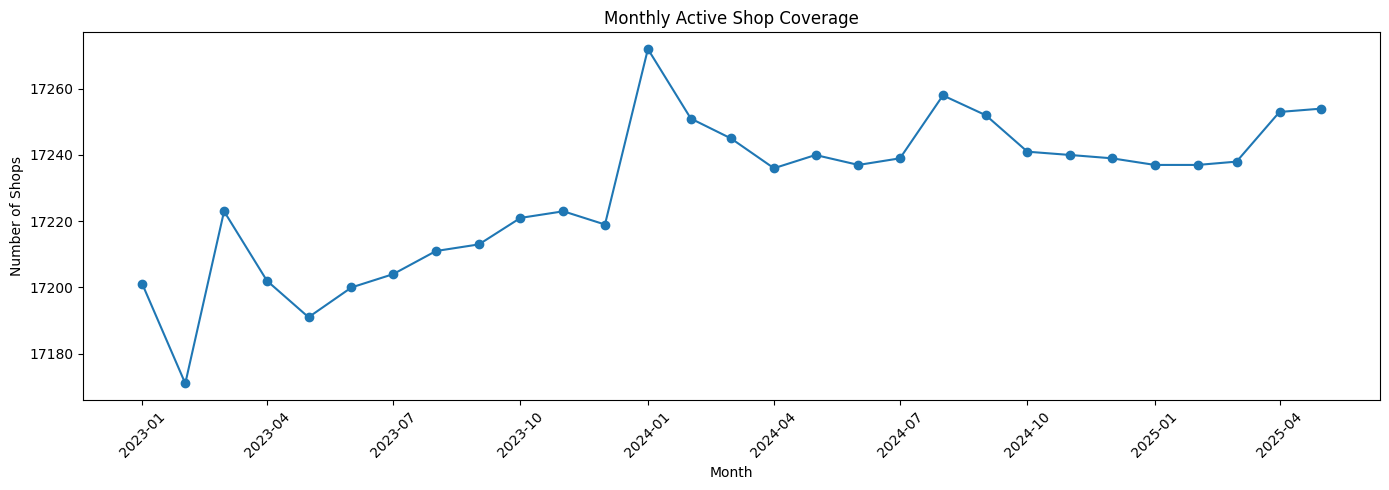

In [ ]:
monthly_counts = (shop_month.groupby("date")["shopNo"].nunique())
plt.figure(figsize=(14, 5))
plt.plot(monthly_counts.index,monthly_counts.values,marker="o")
plt.title("Monthly Active Shop Coverage")
plt.xlabel("Month")
plt.ylabel("Number of Shops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ii. Transaction trend

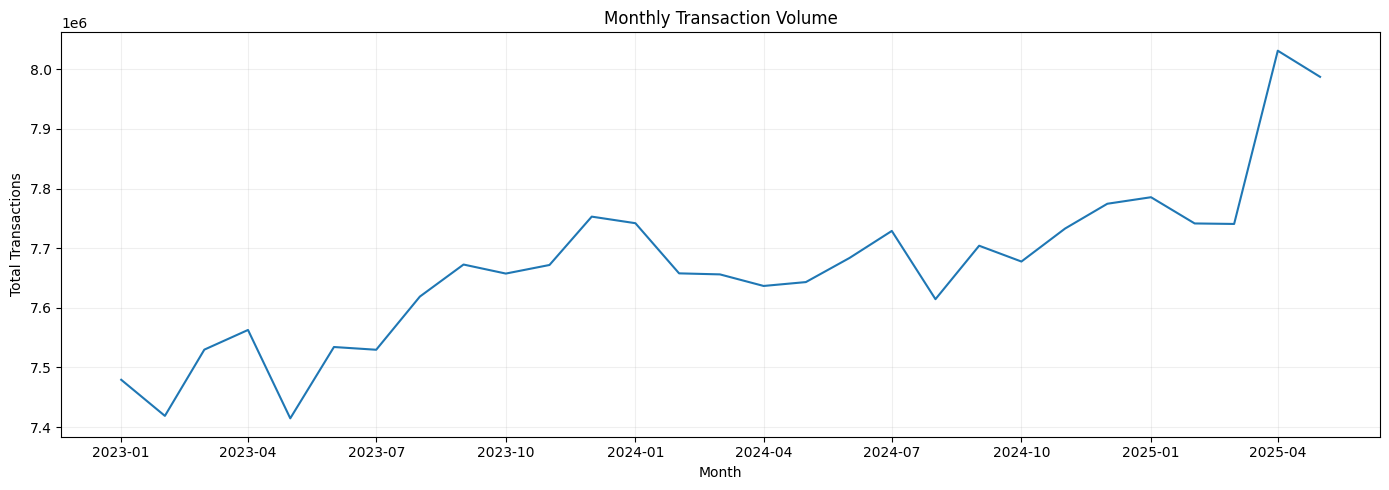

In [ ]:
monthly_transactions = (shop_month.groupby("date")["noOfTrans"].sum())
plt.figure(figsize=(14, 5))
plt.plot(monthly_transactions.index,monthly_transactions.values)
plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Total Transactions")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

iii. Portability trend

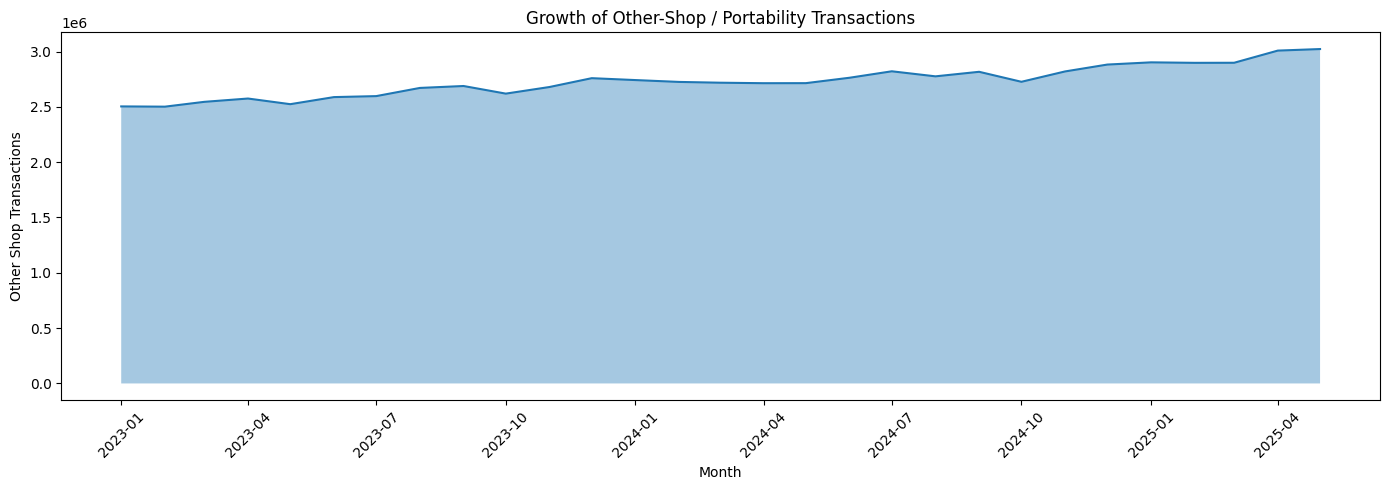

In [ ]:
monthly_portability = (shop_month.groupby("date")["otherShopTransCnt"].sum())
plt.figure(figsize=(14, 5))
plt.fill_between(monthly_portability.index,monthly_portability.values,alpha=0.4)
plt.plot(monthly_portability.index,monthly_portability.values)
plt.title("Growth of Other-Shop / Portability Transactions")
plt.xlabel("Month")
plt.ylabel("Other Shop Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

iv. Portability percentage

In [ ]:
shop_month["portability_rate"] = np.where(
    shop_month["noOfTrans"] > 0,
    shop_month["otherShopTransCnt"] /
    shop_month["noOfTrans"],
    np.nan)

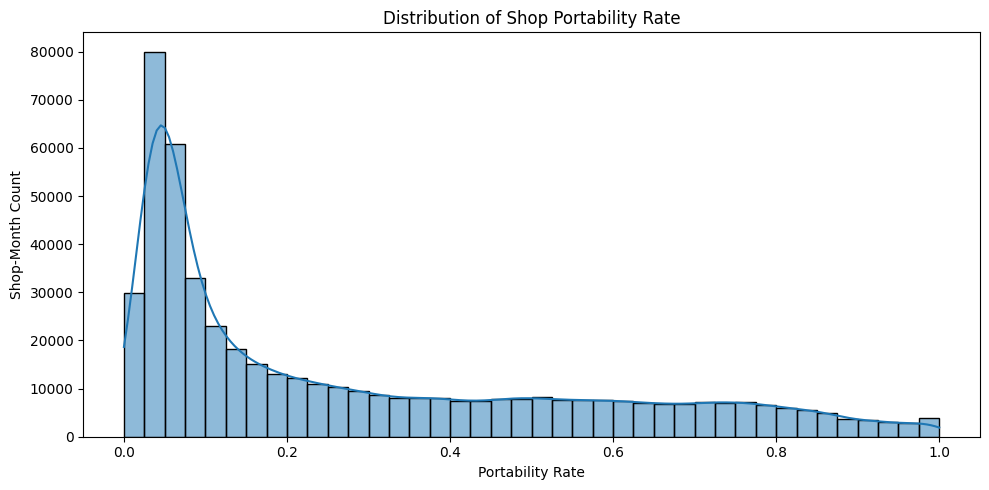

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(shop_month["portability_rate"].dropna(),bins=40,kde=True)
plt.title("Distribution of Shop Portability Rate")
plt.xlabel("Portability Rate")
plt.ylabel("Shop-Month Count")
plt.tight_layout()
plt.show()

v. Transactions vs card entitlement

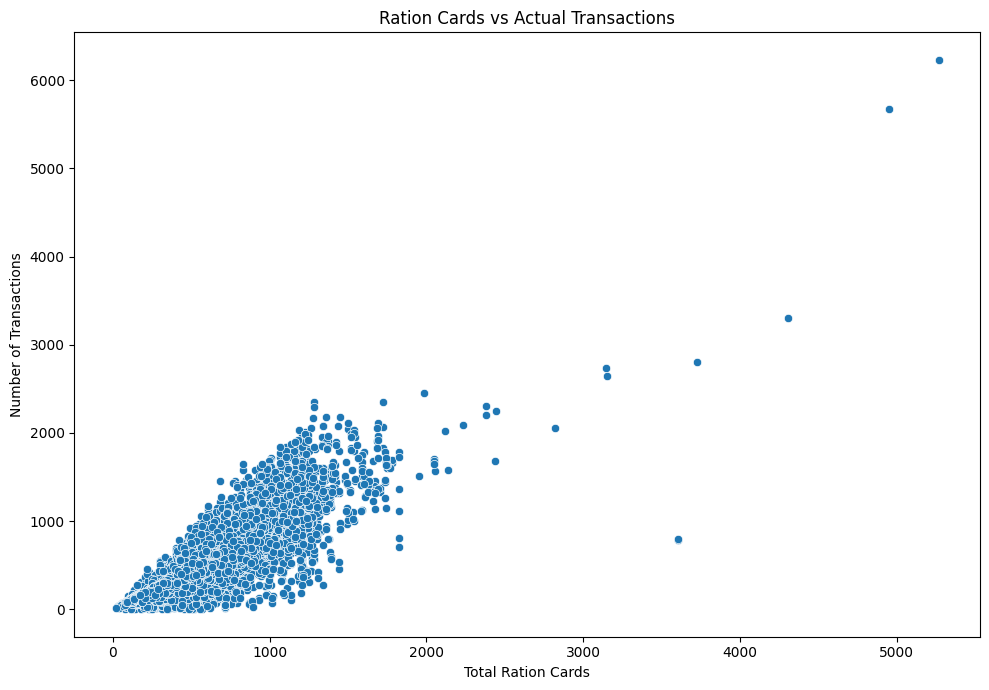

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=shop_month.sample(min(30000, len(shop_month)),random_state=42),x="totalRcs",y="noOfTrans")
plt.title("Ration Cards vs Actual Transactions")
plt.xlabel("Total Ration Cards")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

vi. District transaction distribution — boxplot

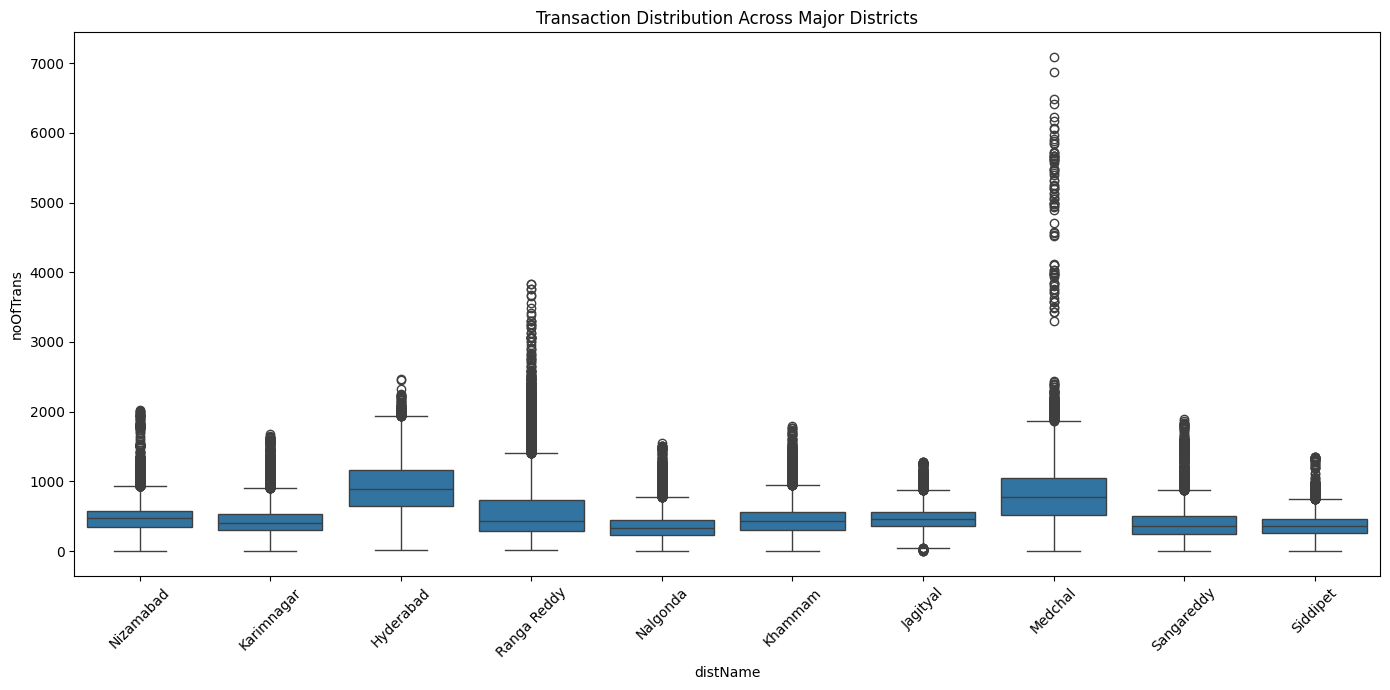

In [ ]:
top_districts = (shop_month.groupby("distName")["noOfTrans"].sum().nlargest(10).index)

plot_df = shop_month[shop_month["distName"].isin(top_districts)]
plt.figure(figsize=(14, 7))
sns.boxplot(data=plot_df,x="distName",y="noOfTrans")
plt.xticks(rotation=45)
plt.title("Transaction Distribution Across Major Districts")
plt.tight_layout()
plt.show()

vii. District heatmap

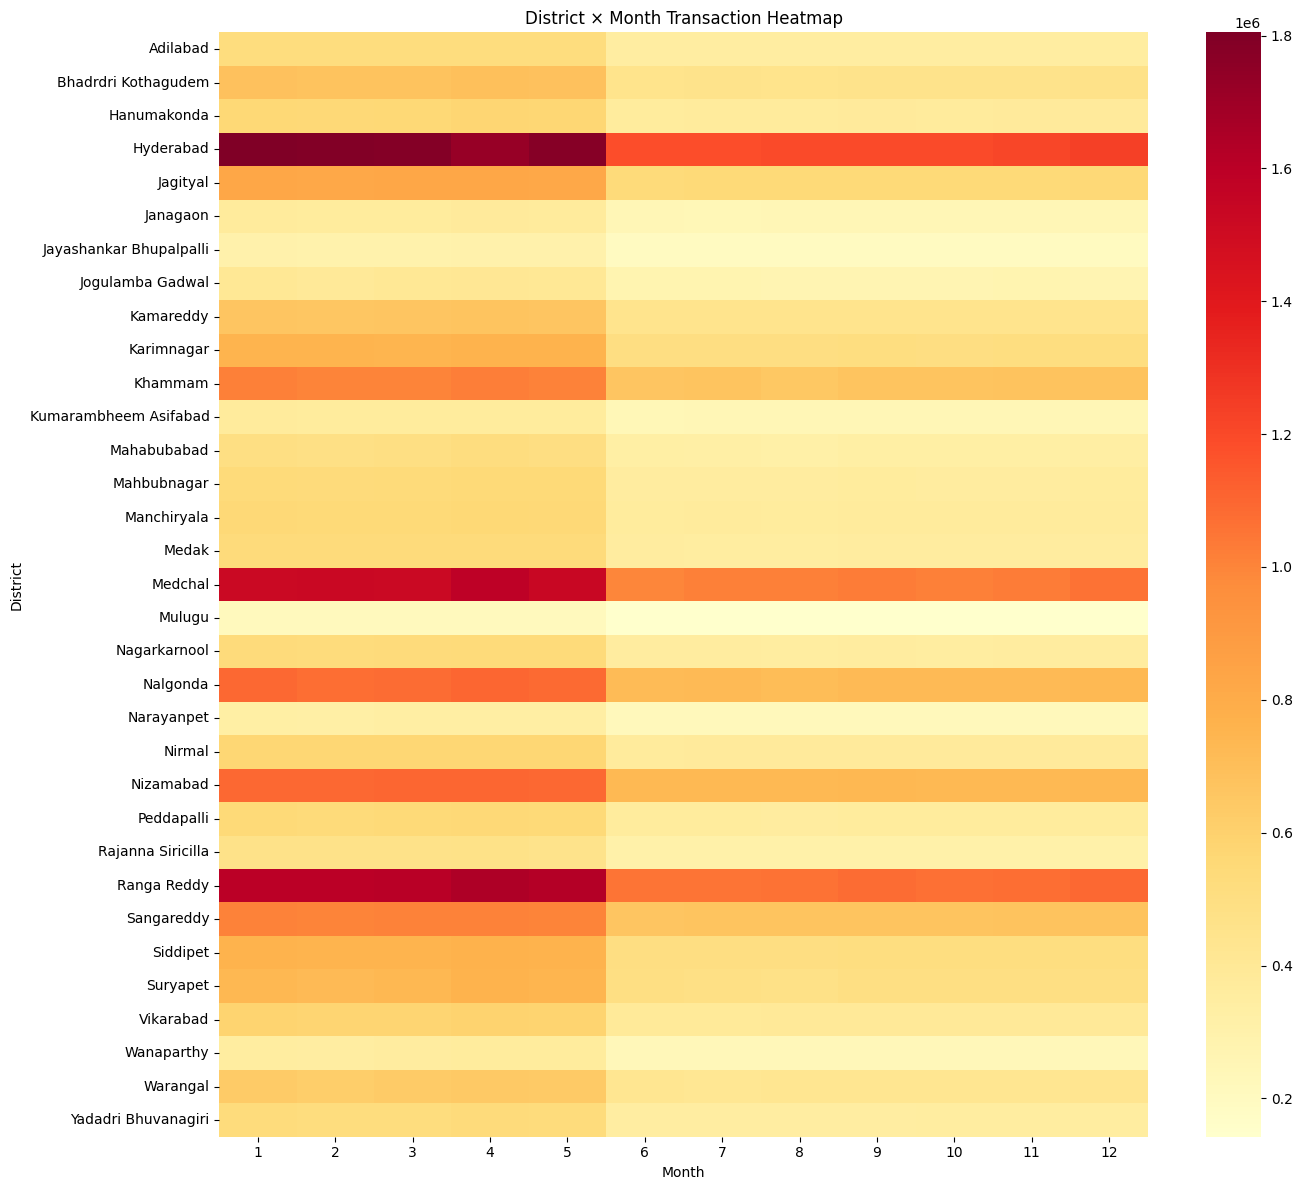

In [ ]:
district_month = (shop_month.pivot_table(index="distName",columns="month",values="noOfTrans",aggfunc="sum"))
plt.figure(figsize=(14, 12))
sns.heatmap(district_month,cmap="YlOrRd")
plt.title("District × Month Transaction Heatmap")
plt.xlabel("Month")
plt.ylabel("District")
plt.tight_layout()
plt.show()

viii. Commodity composition

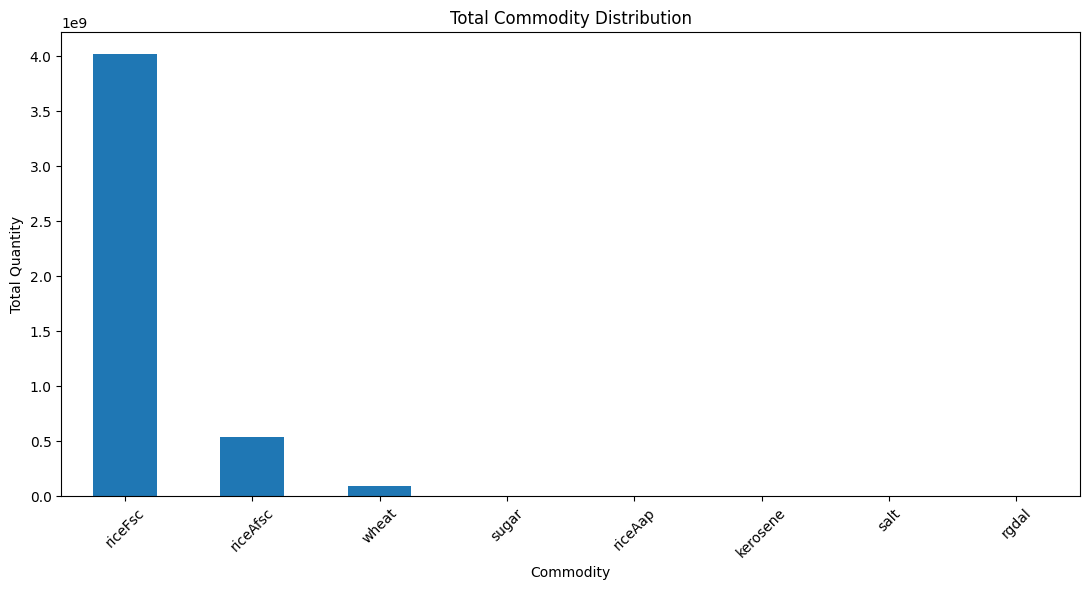

In [ ]:
commodity_cols = ["riceAfsc","riceFsc","riceAap","wheat","sugar","rgdal","kerosene","salt"]
commodity_totals = (shop_month[commodity_cols].sum().sort_values(ascending=False))
plt.figure(figsize=(11, 6))
commodity_totals.plot(kind="bar")
plt.title("Total Commodity Distribution")
plt.xlabel("Commodity")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ix. Commodity composition

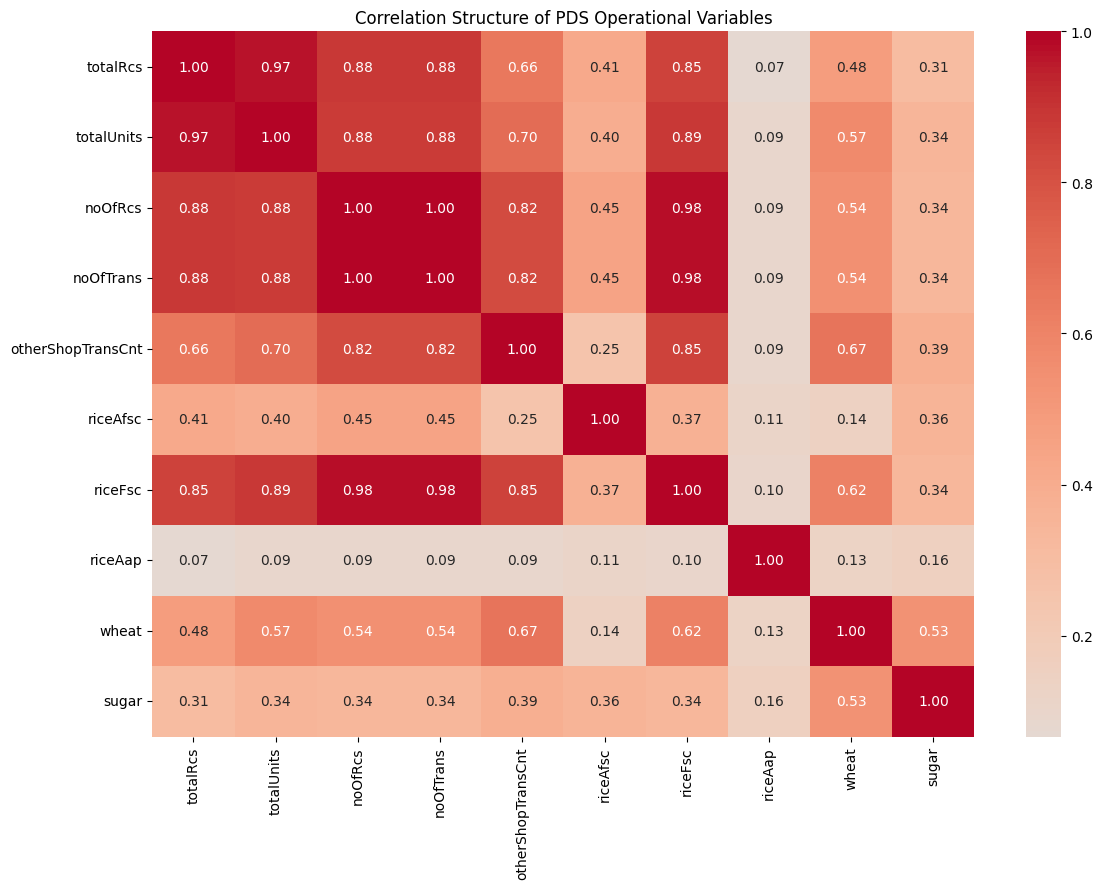

In [ ]:
corr_cols = ["totalRcs","totalUnits","noOfRcs","noOfTrans","otherShopTransCnt","riceAfsc","riceFsc","riceAap","wheat","sugar"]
corr = shop_month[corr_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Structure of PDS Operational Variables")
plt.tight_layout()
plt.show()

# 28: Feature engineering

In [ ]:
#1. Utilization
shop_month["utilization_rate"] = np.where(shop_month["totalRcs"] > 0,shop_month["noOfTrans"] / shop_month["totalRcs"],np.nan)

In [ ]:
#2. Transactions per ration card
shop_month["transactions_per_card"] = np.where(shop_month["totalRcs"] > 0,shop_month["noOfTrans"]/shop_month["totalRcs"],np.nan)

In [ ]:
#3. Rice quantity
rice_cols = ["riceAfsc","riceFsc","riceAap"]
shop_month["total_rice"] = (shop_month[rice_cols].sum(axis=1))

In [ ]:
#4. Rice intensity
shop_month["rice_intensity"] = np.where(
    shop_month["total_rice"] + shop_month["wheat"] > 0,
    shop_month["total_rice"] / (shop_month["total_rice"] + shop_month["wheat"]),np.nan)

In [ ]:
#5. Portability rate
shop_month["portability_rate"]

,portability_rate
0,0.036611
1,0.045977
2,0.067669
3,0.051491
4,0.036105
...,...
499643,0.042553
499644,0.142670
499645,0.023333
499646,0.032710


# 29: Shop-level aggregation

In [ ]:
shop_features = (shop_month.groupby(["distCode", "shopNo"],
        as_index=False).agg(avg_transactions=("noOfTrans","mean"),
        median_transactions=("noOfTrans","median"),
        transaction_std=("noOfTrans","std"),
        max_transactions=("noOfTrans","max"),
        avg_cards=("totalRcs","mean"),
        avg_units=("totalUnits","mean"),
        avg_utilization=("utilization_rate","mean"),
        avg_transactions_per_card=("transactions_per_card","mean"),
        avg_portability=("portability_rate","mean"),
        portability_std=("portability_rate","std"),
        avg_rice_intensity=("rice_intensity","mean"),
        total_rice=("total_rice","sum"),
        total_wheat=("wheat","sum"),
        total_sugar=("sugar","sum"),
        months_observed=("date","nunique")))

In [ ]:
print("Shop-level feature matrix:",shop_features.shape)
display(shop_features.head())

Shop-level feature matrix: (17491, 17)


,distCode,shopNo,avg_transactions,median_transactions,transaction_std,max_transactions,avg_cards,avg_units,avg_utilization,avg_transactions_per_card,avg_portability,portability_std,avg_rice_intensity,total_rice,total_wheat,total_sugar,months_observed
0,532,1901001,950.586207,952.0,23.304686,988,1107.931034,3391.068966,0.857983,0.857983,0.037761,0.005614,1.0,533767.0,0.0,0.0,29
1,532,1901002,519.206897,520.0,7.485125,533,584.000000,1877.655172,0.889053,0.889053,0.053426,0.007895,1.0,299649.0,0.0,0.0,29
2,532,1901003,267.000000,267.0,4.735881,276,292.310345,952.551724,0.913427,0.913427,0.073283,0.015791,1.0,155371.0,0.0,0.0,29
3,532,1901004,364.103448,364.0,3.255159,370,405.000000,1350.172414,0.899021,0.899021,0.036998,0.007892,1.0,217867.0,0.0,0.0,29
4,532,1901005,911.689655,909.0,13.164084,954,977.758621,3338.206897,0.932630,0.932630,0.033150,0.004069,1.0,609701.0,0.0,0.0,29


# 30: Transaction growth feature

In [ ]:
shop_month_sorted = shop_month.sort_values(["shopNo", "date"])

In [ ]:
first_last = (shop_month_sorted.groupby(["distCode", "shopNo"])
    .agg(first_transactions=("noOfTrans","first"),last_transactions=("noOfTrans","last")).reset_index())

In [ ]:
#Calculate growth
first_last["transaction_growth"] = np.where(
    first_last["first_transactions"] > 0,
    (first_last["last_transactions"] - first_last["first_transactions"]) / first_last["first_transactions"],np.nan)

In [ ]:
#Merge
shop_features = shop_features.merge(
    first_last[["distCode","shopNo","transaction_growth"]],
    on=["distCode","shopNo"],how="left")

# 31: Clean ML features

In [ ]:
ml_features = ["avg_transactions","median_transactions","transaction_std","avg_cards","avg_units","avg_utilization","avg_transactions_per_card",
    "avg_portability","portability_std","avg_rice_intensity","total_rice","total_wheat","total_sugar","transaction_growth",
    "months_observed"]

In [ ]:
# Create matrix:
X = shop_features[ml_features].copy()

# Check:
print(X.shape)

display(X.isna().sum().sort_values(ascending=False))

(17491, 15)


,0
avg_transactions,0
median_transactions,0
transaction_std,0
avg_cards,0
avg_units,0
avg_utilization,0
avg_transactions_per_card,0
avg_portability,0
portability_std,0
avg_rice_intensity,0


# 32: Missing values for ML

In [ ]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(X_imputed,columns=X.columns,index=X.index)

print("Remaining missing values:",X_imputed.isna().sum().sum())

Remaining missing values: 0


# 33: Remove extreme infinities

In [ ]:
X_imputed = X_imputed.replace([np.inf, -np.inf],np.nan )

In [ ]:
X_imputed = X_imputed.fillna(X_imputed.median())

# 35:  StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (17491, 15)


# 36: PCA - Principal Component Analysis

In [ ]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

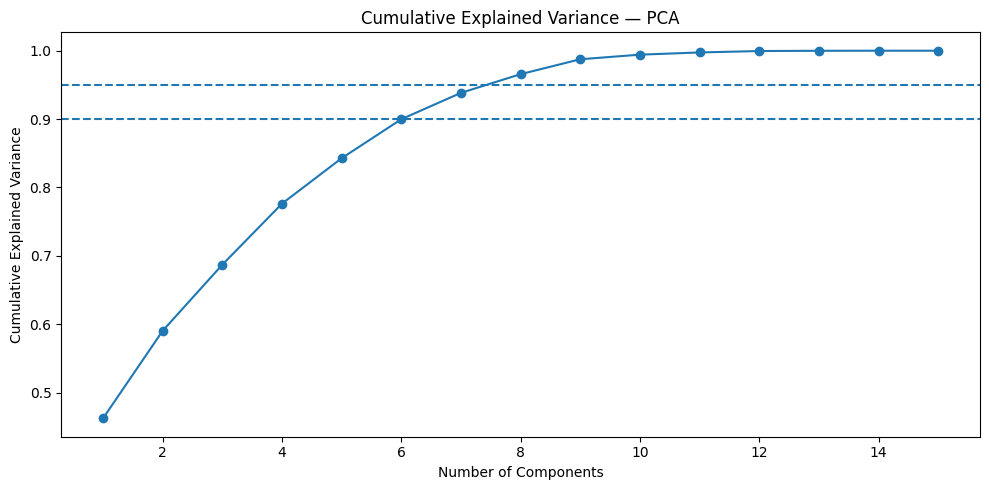

In [ ]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1,len(cumulative_variance) + 1), cumulative_variance, marker="o" )
plt.axhline(0.90,linestyle="--")
plt.axhline(0.95,linestyle="--")
plt.title("Cumulative Explained Variance — PCA")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [ ]:
print("Explained variance by component:")
for i, value in enumerate(pca_full.explained_variance_ratio_,start=1):
  print(f"PC{i}:{value:.3%}")

Explained variance by component:
PC1: 46.239%
PC2: 12.806%
PC3: 9.667%
PC4: 8.923%
PC5: 6.644%
PC6: 5.705%
PC7: 3.854%
PC8: 2.734%
PC9: 2.180%
PC10: 0.671%
PC11: 0.325%
PC12: 0.205%
PC13: 0.036%
PC14: 0.011%
PC15: 0.000%


# 37: PCA for visualization

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

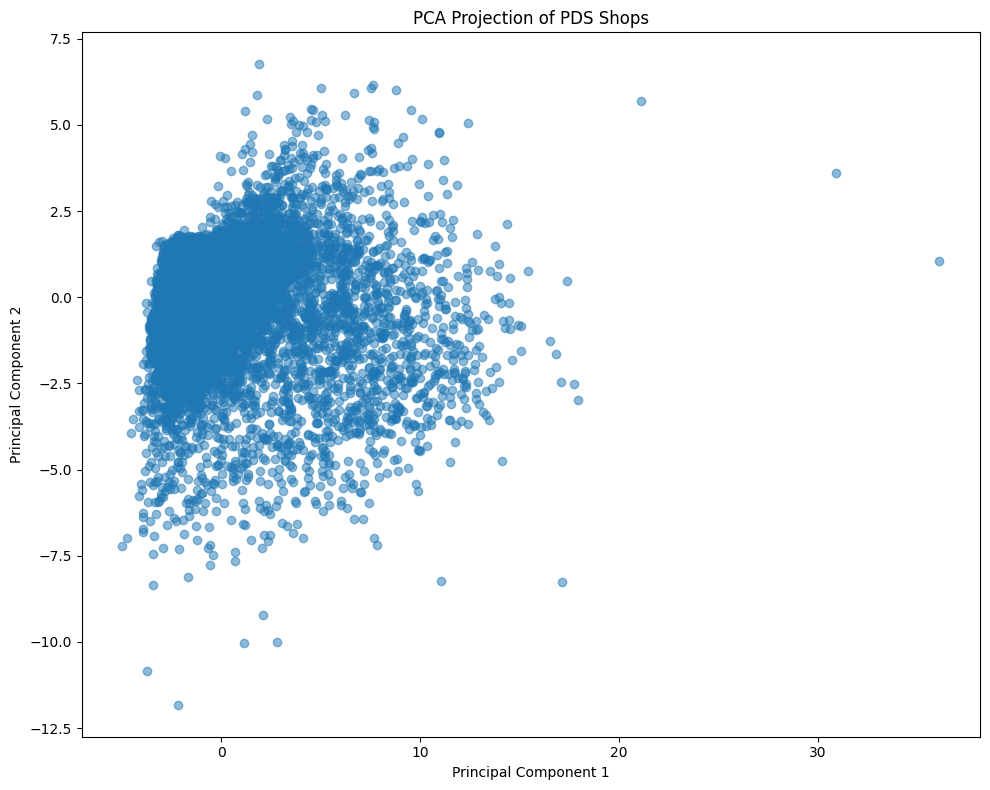

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.5)
plt.title("PCA Projection of PDS Shops")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

#38: PCA loadings

In [ ]:
loadings = pd.DataFrame(pca_2d.components_.T,index=ml_features,columns=["PC1", "PC2"] )
display(loadings.sort_values("PC1",key=abs,ascending=False))

,PC1,PC2
total_rice,0.361664,0.102775
avg_transactions,0.359022,0.112858
median_transactions,0.358997,0.113043
avg_units,0.336525,-0.134169
avg_cards,0.323376,-0.120131
total_wheat,0.283032,-0.213135
transaction_std,0.253045,-0.267075
avg_rice_intensity,-0.251251,0.287997
avg_portability,0.225396,-0.117294
total_sugar,0.224501,-0.171863


# 39: K-Means

In [ ]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []
for k in k_values:
      model = KMeans(n_clusters=k,random_state=42,n_init=20)
      labels = model.fit_predict(X_scaled)
      inertias.append(model.inertia_)
      silhouette_scores.append(silhouette_score(X_scaled,labels))

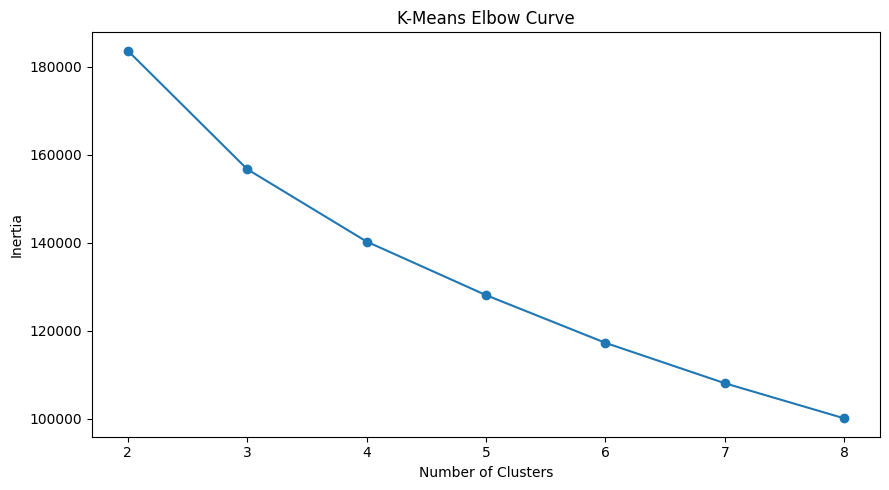

In [ ]:
# Elbow
plt.figure(figsize=(9, 5))
plt.plot(list(k_values),inertias,marker="o")
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

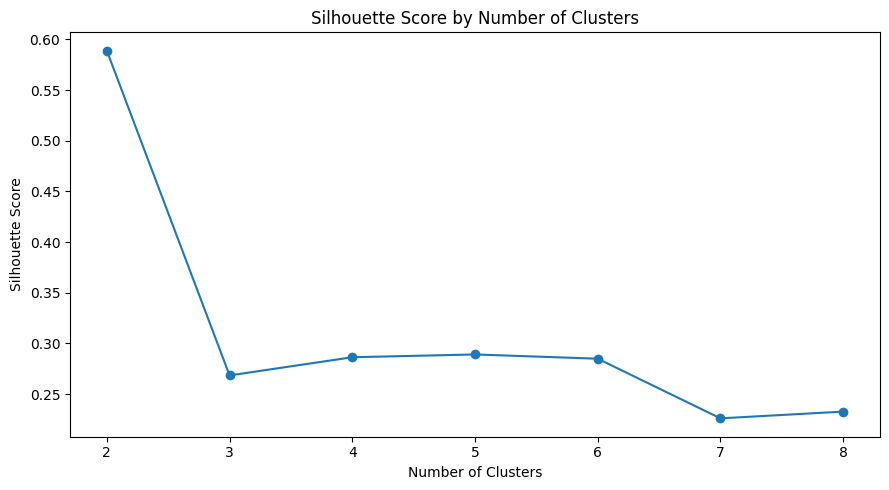

In [ ]:
#Silhouette
plt.figure(figsize=(9, 5))
plt.plot(list(k_values),silhouette_scores,marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# 40: Final K-Means model

In [ ]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=20)
shop_features["cluster"] = (kmeans.fit_predict(X_scaled))

In [ ]:
shop_features["cluster"].value_counts()

,count
cluster,
2,10580
0,5376
1,1148
3,387


# 41: Cluster profiling

In [ ]:
cluster_profile = (shop_features.groupby("cluster")[ml_features].mean().round(3))
display(cluster_profile)

,avg_transactions,median_transactions,transaction_std,avg_cards,avg_units,avg_utilization,avg_transactions_per_card,avg_portability,portability_std,avg_rice_intensity,total_rice,total_wheat,total_sugar,transaction_growth,months_observed
cluster,,,,,,,,,,,,,,,
0,603.292,605.638,39.958,671.253,2086.175,0.915,0.915,0.385,0.027,0.996,353704.794,1206.328,90.915,0.136,28.965
1,1062.473,1069.220,119.423,1039.508,3644.298,1.038,1.038,0.748,0.023,0.893,676301.374,77959.893,838.595,0.243,28.922
2,298.851,299.242,19.802,391.596,1197.167,0.776,0.776,0.182,0.033,0.999,174296.544,138.812,36.241,0.182,28.949
3,355.400,368.642,60.671,469.209,1470.746,0.801,0.801,0.263,0.112,0.995,83858.625,226.370,12.036,0.236,11.499


In [ ]:
cluster_sizes = (shop_features["cluster"].value_counts().sort_index())
print(cluster_sizes)

cluster
0     5376
1     1148
2    10580
3      387
Name: count, dtype: int64


# 42: Visualize clusters using PCA

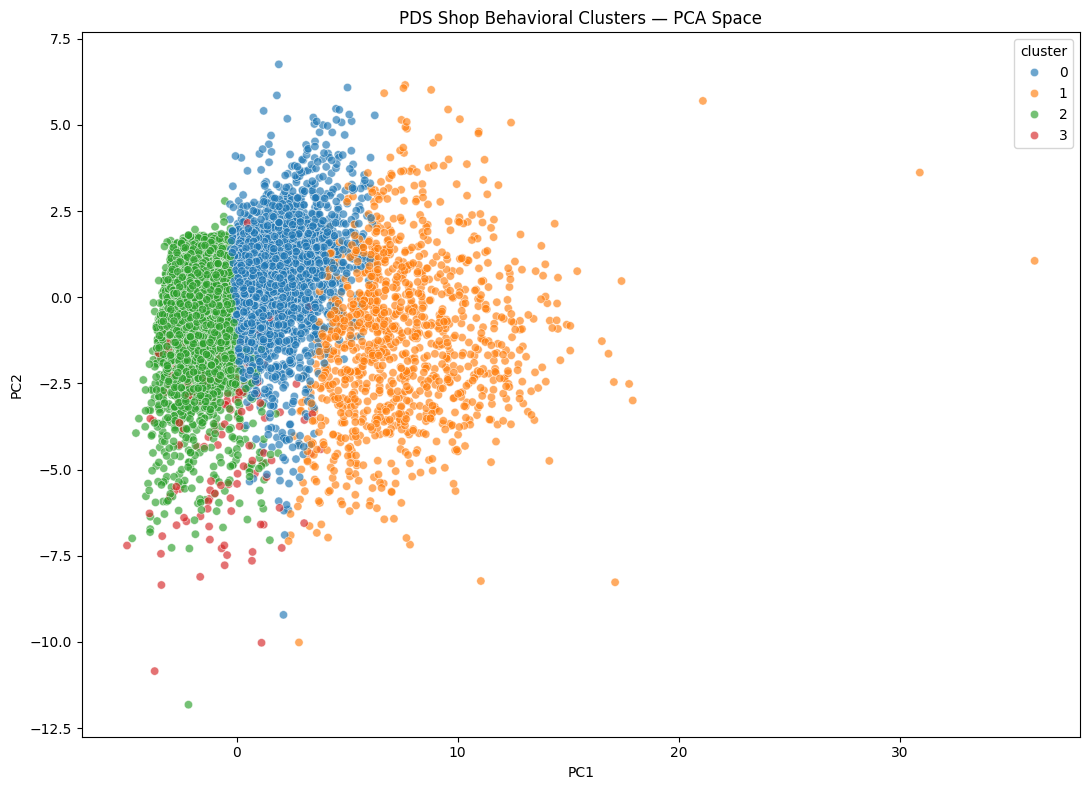

In [ ]:
pca_plot_df = pd.DataFrame({"PC1": X_pca_2d[:, 0],"PC2": X_pca_2d[:, 1],"cluster": shop_features["cluster"]})
plt.figure(figsize=(11, 8))
sns.scatterplot(data=pca_plot_df,x="PC1",y="PC2",hue="cluster",palette="tab10",alpha=0.65)
plt.title("PDS Shop Behavioral Clusters — PCA Space")
plt.tight_layout()
plt.show()

#43:  DBSCAN

In [ ]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

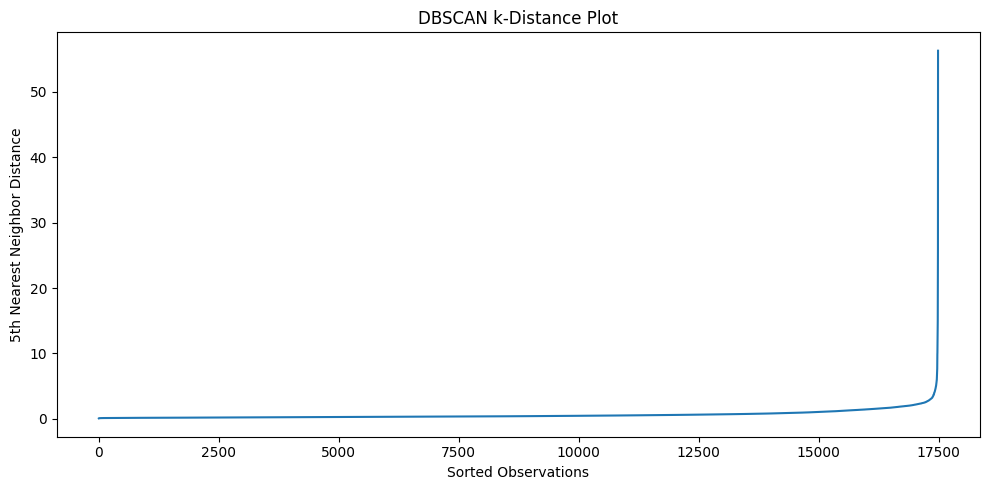

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title("DBSCAN k-Distance Plot")
plt.xlabel("Sorted Observations")
plt.ylabel("5th Nearest Neighbor Distance")
plt.tight_layout()
plt.show()

In [ ]:
dbscan = DBSCAN(eps=1.2,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [ ]:
shop_features["dbscan_label"] = dbscan_labels

In [ ]:
shop_features["dbscan_label" ].value_counts().sort_index()

,count
dbscan_label,
-1,1645
0,15496
1,36
2,41
3,5
4,5
5,6
6,5
7,7


# 44: Anomaly profiling

In [ ]:
anomalies = shop_features[shop_features["dbscan_label"] == -1].copy()

In [ ]:
print("Number of potential behavioral anomalies:",len(anomalies))

Number of potential behavioral anomalies: 1645


In [ ]:
normal = shop_features[shop_features["dbscan_label"] != -1 ]

In [ ]:
anomaly_summary = pd.DataFrame({"Anomaly_Mean": anomalies[ml_features].mean(), "Normal_Mean": normal[ml_features].mean()})
anomaly_summary["Difference"] = (anomaly_summary["Anomaly_Mean"] - anomaly_summary["Normal_Mean"] )
display(anomaly_summary.sort_values("Difference",key=abs,ascending=False))

,Anomaly_Mean,Normal_Mean,Difference
total_rice,492493.805471,236291.137259,256202.668213
total_wheat,50392.991489,924.078506,49468.912984
avg_units,2981.377116,1497.524329,1483.852787
total_sugar,628.282675,50.866149,577.416526
median_transactions,805.015502,408.164269,396.851233
avg_transactions,798.659124,406.954807,391.704317
avg_cards,872.049423,485.432093,386.617330
transaction_std,109.059019,25.589611,83.469408
months_observed,27.223100,28.705415,-1.482314
transaction_growth,1.278948,0.058400,1.220548


# 45: Geospatial analysis

In [ ]:
#Attach coordinates

shop_features = shop_features.merge(
    location_lookup[["distCode","shopNo","latitude","longitude","distName","officeName"]],
    on=["distCode","shopNo"], how="left")

In [ ]:
display(shop_features.head())

,distCode,shopNo,avg_transactions,median_transactions,transaction_std,max_transactions,avg_cards,avg_units,avg_utilization,avg_transactions_per_card,...,total_wheat,total_sugar,months_observed,transaction_growth,cluster,dbscan_label,latitude,longitude,distName,officeName
0,532,1901001,950.586207,952.0,23.304686,988,1107.931034,3391.068966,0.857983,0.857983,...,0.0,0.0,29,-0.017472,0,0,19.641643,78.391212,Adilabad,Talamadugu
1,532,1901002,519.206897,520.0,7.485125,533,584.000000,1877.655172,0.889053,0.889053,...,0.0,0.0,29,0.015414,0,0,19.669093,78.422012,Adilabad,Talamadugu
2,532,1901003,267.000000,267.0,4.735881,276,292.310345,952.551724,0.913427,0.913427,...,0.0,0.0,29,0.082353,2,0,19.664645,78.427186,Adilabad,Talamadugu
3,532,1901004,364.103448,364.0,3.255159,370,405.000000,1350.172414,0.899021,0.899021,...,0.0,0.0,29,0.013812,2,0,19.696032,78.381016,Adilabad,Talamadugu
4,532,1901005,911.689655,909.0,13.164084,954,977.758621,3338.206897,0.932630,0.932630,...,0.0,0.0,29,0.016722,0,0,19.697063,78.351118,Adilabad,Talamadugu


In [ ]:
display(location_lookup.head())

,distCode,shopNo,distName,officeCode,officeName,address,longitude,latitude,fpsStatus,fpsType
0,532,1901001,Adilabad,532001,Talamadugu,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop
1,532,1901002,Adilabad,532001,Talamadugu,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop
2,532,1901003,Adilabad,532001,Talamadugu,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop
3,532,1901004,Adilabad,532001,Talamadugu,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop
4,532,1901005,Adilabad,532001,Talamadugu,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop


In [ ]:
# Create Map
center_lat = shop_features["latitude"].median()
center_lon = shop_features["longitude"].median()
m = folium.Map(location=[center_lat,center_lon],zoom_start=7)

In [ ]:
#Add shops

sample_map = shop_features.dropna(subset = ["latitude", "longitude"]).sample(min(5000, len(shop_features)), random_state=42)

for _, row in sample_map.iterrows():
    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]],
        radius=3,

        popup=(
            f"Shop: {row['shopNo']}<br>"
            f"District: {row['distName']}<br>"
            f"Cluster: {row['cluster']}<br>"
            f"DBSCAN: {row['dbscan_label']}"
        ),

        fill=True
    ).add_to(m)

# 46: Save the ML outputs

In [ ]:
shop_features.to_parquet( PROCESSED_DIR / "shop_features_with_clusters.parquet", index=False)

#Also save the cluster profile:
cluster_profile.to_csv(REPORT_DIR / "cluster_profile.csv")

STREAMLIT

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

from pathlib import Path


# ==========================================
# CONFIGURATION
# ==========================================

st.set_page_config(
    page_title="Telangana PDS Analytics",
    page_icon="📊",
    layout="wide"
)


# ==========================================
# LOAD DATA
# ==========================================

@st.cache_data
def load_data():

    base = Path("processed")

    df = pd.read_parquet(
        base /
        "shop_features_with_clusters.parquet"
    )

    return df


df = load_data()


# ==========================================
# TITLE
# ==========================================

st.title(
    "Telangana PDS Analytics"
)

st.caption(
    "Multi-Dimensional Shop Performance "
    "Clustering & Anomaly Profiling"
)


# ==========================================
# SIDEBAR
# ==========================================

st.sidebar.header(
    "Filters"
)


districts = sorted(
    df["distName"]
    .dropna()
    .unique()
)

selected_districts = st.sidebar.multiselect(
    "District",
    districts,
    default=districts
)


filtered_df = df[
    df["distName"].isin(
        selected_districts
    )
]


# ==========================================
# KPI CARDS
# ==========================================

col1, col2, col3, col4 = st.columns(4)


col1.metric(
    "Total Shops",
    filtered_df["shopNo"].nunique()
)

col2.metric(
    "Clusters",
    filtered_df["cluster"].nunique()
)

col3.metric(
    "Potential Anomalies",
    (
        filtered_df["dbscan_label"] == -1
    ).sum()
)

col4.metric(
    "Avg Transactions",
    round(
        filtered_df[
            "avg_transactions"
        ].mean(),
        2
    )
)


# ==========================================
# CLUSTER DISTRIBUTION
# ==========================================

st.subheader(
    "Shop Cluster Distribution"
)

cluster_counts = (
    filtered_df["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = [
    "Cluster",
    "Shop Count"
]

fig = px.bar(
    cluster_counts,
    x="Cluster",
    y="Shop Count",
    title="Behavioral Cluster Distribution"
)

st.plotly_chart(
    fig,
    use_container_width=True
)


# ==========================================
# CLUSTER PROFILE
# ==========================================

st.subheader(
    "Cluster Profile"
)

profile = (
    filtered_df
    .groupby("cluster")[
        [
            "avg_transactions",
            "avg_cards",
            "avg_utilization",
            "avg_portability",
            "transaction_growth"
        ]
    ]
    .mean()
    .round(3)
)

st.dataframe(
    profile,
    use_container_width=True
)


# ==========================================
# SHOP SEARCH
# ==========================================

st.subheader(
    "Shop Deep Dive"
)

shop_input = st.text_input(
    "Enter Shop Number"
)

if shop_input:

    result = df[
        df["shopNo"].astype(str)
        == shop_input.strip()
    ]

    if len(result) == 0:

        st.warning(
            "Shop not found."
        )

    else:

        st.dataframe(
            result,
            use_container_width=True
        )

In [ ]:
"""
Streamlit Web Application: Telangana PDS Analytics Platform.

Provides interactive dashboards for executive spatial analysis, cluster persona deep-dives,
and automated shop anomaly profiling.
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import MarkerCluster
from streamlit_folium import st_folium
from pathlib import Path

# Page Layout Setup
st.set_page_config(
    page_title="Telangana PDS Analytics Platform",
    page_icon="🌾",
    layout="wide",
    initial_sidebar_state="expanded"
)

@st.cache_data
def load_processed_data() -> pd.DataFrame:
    """Loads clustered dataset from parquet store."""
    file_path = Path("processed/shop_features_modeled.parquet")
    if file_path.exists():
        return pd.read_parquet(file_path)
    else:
        # Fallback simulation generator for local testing
        np.random.seed(42)
        n = 500
        return pd.DataFrame({
            "dist_code": np.random.choice([1, 2, 3], n),
            "shop_no": np.arange(1000, 1000 + n),
            "dist_name": np.random.choice(["HYDERABAD", "WARANGAL", "KARIMNAGAR"], n),
            "latitude": np.random.uniform(17.0, 18.5, n),
            "longitude": np.random.uniform(78.0, 79.5, n),
            "avg_transactions": np.random.exponential(400, n),
            "avg_entitled_cards": np.random.normal(500, 100, n),
            "avg_utilization_ratio": np.random.uniform(0.4, 0.95, n),
            "avg_portability_rate": np.random.uniform(0.01, 0.35, n),
            "pc1": np.random.normal(0, 1, n),
            "pc2": np.random.normal(0, 1, n),
            "cluster_id": np.random.choice([0, 1, 2, 3], n),
            "is_anomaly": np.random.choice([0, 1], n, p=[0.93, 0.07]),
            "dbscan_label": np.random.choice([0, -1], n, p=[0.93, 0.07])
        })

# Load Data
df = load_processed_data()

# Executive Dashboard Header
st.title("🌾 Telangana PDS Analytics Platform")
st.markdown("### Multi-Dimensional Shop Performance Clustering & Anomaly Profiling")

# Sidebar Controls
st.sidebar.header("🕹️ Executive Control Panel")

all_districts = sorted(df["dist_name"].dropna().unique().tolist())
selected_districts = st.sidebar.multiselect(
    "Filter District(s)",
    options=all_districts,
    default=all_districts
)

cluster_filter = st.sidebar.multiselect(
    "Filter Behavioral Personas",
    options=sorted(df["cluster_id"].unique().tolist()),
    default=sorted(df["cluster_id"].unique().tolist())
)

show_anomalies_only = st.sidebar.checkbox("Show Flagged Anomalies Only (-1)", value=False)

# Apply Filter Cascade
filtered_df = df[
    (df["dist_name"].isin(selected_districts)) &
    (df["cluster_id"].isin(cluster_filter))
]

if show_anomalies_only:
    filtered_df = filtered_df[filtered_df["is_anomaly"] == 1]

# Top KPI Metric Cards
c1, c2, c3, c4, c5 = st.columns(5)
c1.metric("Active Shops", f"{len(filtered_df):,}")
c2.metric("Districts Monitored", f"{filtered_df['dist_name'].nunique()}")
c3.metric("Flagged Anomalies", f"{filtered_df['is_anomaly'].sum():,}", delta_color="inverse")
c4.metric("Avg Utilization", f"{filtered_df['avg_utilization_ratio'].mean():.1%}")
c5.metric("Portability Traffic", f"{filtered_df['avg_portability_rate'].mean():.1%}")

st.markdown("---")

# Tab Layout Navigation
tab_map, tab_clusters, tab_lookup, tab_reports = st.tabs([
    "🗺️ Geospatial Hotspot Map",
    "📊 PCA Cluster Spaces",
    "🔍 Shop Deep-Dive Lookup",
    "📄 Executive Anomaly Report"
])

with tab_map:
    st.subheader("Geospatial Distribution & Portability Hub Hotspots")

    map_data = filtered_df.dropna(subset=["latitude", "longitude"])

    if map_data.empty:
        st.warning("No location data available for current selection.")
    else:
        # Center Map
        center_lat = map_data["latitude"].median()
        center_lon = map_data["longitude"].median()

        m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="CartoDB positron")
        marker_cluster = MarkerCluster().add_to(m)

        color_palette = {0: "blue", 1: "green", 2: "orange", 3: "purple"}

        # Display sample points on map
        for _, row in map_data.head(800).iterrows():
            is_anom = row["is_anomaly"] == 1
            color = "red" if is_anom else color_palette.get(row["cluster_id"], "gray")

            popup_html = f"""
            <b>Shop ID:</b> {row['shop_no']}<br>
            <b>District:</b> {row['dist_name']}<br>
            <b>Cluster Persona:</b> {row['cluster_id']}<br>
            <b>Utilization:</b> {row['avg_utilization_ratio']:.1%}<br>
            <b>Anomaly Flag:</b> {'YES' if is_anom else 'NO'}
            """

            folium.CircleMarker(
                location=[row["latitude"], row["longitude"]],
                radius=6 if is_anom else 4,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7,
                popup=folium.Popup(popup_html, max_width=250)
            ).add_to(marker_cluster)

        st_folium(m, width=1200, height=550)

with tab_clusters:
    st.subheader("High-Dimensional Behavioral Separation (PCA Projections)")

    col_left, col_right = st.columns([2, 1])

    with col_left:
        fig_pca = px.scatter(
            filtered_df,
            x="pc1",
            y="pc2",
            color=filtered_df["cluster_id"].astype(str),
            symbol=filtered_df["is_anomaly"].map({0: "Normal", 1: "Anomaly"}),
            labels={"color": "Cluster Persona", "symbol": "Status"},
            title="PCA Dimension Projection (PC1 vs PC2)",
            hover_data=["shop_no", "dist_name", "avg_transactions"]
        )
        st.plotly_chart(fig_pca, use_container_width=True)

    with col_right:
        st.subheader("Cluster Persona Breakdown")
        profile_df = filtered_df.groupby("cluster_id").agg(
            Shops=("shop_no", "count"),
            Avg_Trans=("avg_transactions", "mean"),
            Utilization=("avg_utilization_ratio", "mean"),
            Portability=("avg_portability_rate", "mean")
        ).round(2)
        st.dataframe(profile_df, use_container_width=True)

with tab_lookup:
    st.subheader("Individual Fair Price Shop Auditor Lookup")

    search_shop = st.text_input("Enter Shop Number (e.g. 1001):")
    if search_shop:
        result = df[df["shop_no"].astype(str) == search_shop.strip()]
        if not result.empty:
            shop_data = result.iloc[0]

            col_a, col_b, col_c = st.columns(3)
            col_a.metric("Shop Number", shop_data["shop_no"])
            col_b.metric("District", shop_data["dist_name"])
            col_c.metric("Cluster Assignment", f"Cluster {shop_data['cluster_id']}")

            st.markdown("#### Operational Metrics vs State Averages")
            metrics_comparison = pd.DataFrame({
                "Metric": ["Avg Transactions", "Capacity Utilization", "Portability Rate"],
                "Shop Value": [
                    f"{shop_data['avg_transactions']:.1f}",
                    f"{shop_data['avg_utilization_ratio']:.1%}",
                    f"{shop_data['avg_portability_rate']:.1%}"
                ],
                "State Benchmark": [
                    f"{df['avg_transactions'].mean():.1f}",
                    f"{df['avg_utilization_ratio'].mean():.1%}",
                    f"{df['avg_portability_rate'].mean():.1%}"
                ]
            })
            st.table(metrics_comparison)

            if shop_data["is_anomaly"] == 1:
                st.error("⚠️ ALERT: This shop has been flagged as an anomalous operational profile by DBSCAN.")
            else:
                st.success("✅ Normal Profile: Shop metrics fall within expected cluster bounds.")
        else:
            st.warning("Shop ID not found in database.")

with tab_reports:
    st.subheader("Anomalous Outlier Priority Queue")
    anomaly_queue = df[df["is_anomaly"] == 1][[
        "dist_name", "shop_no", "cluster_id", "avg_transactions",
        "avg_entitled_cards", "avg_utilization_ratio", "avg_portability_rate"
    ]].sort_values("avg_utilization_ratio", ascending=False)

    st.dataframe(anomaly_queue, use_container_width=True)

    st.download_button(
        label="📥 Download Anomaly Audit CSV Report",
        data=anomaly_queue.to_csv(index=False),
        file_name="telangana_pds_anomalies_audit_report.csv",
        mime="text/csv"
    )